# **Building a Language Model Using Histogram N-Gram Analysis**

This project introduces language modeling by focusing on generating pop song lyrics. You will implement histogram N-gram models using the Natural Language Toolkit (NLTK) to analyze and understand word frequencies and distributions. This approach helps reveal linguistic patterns and repetitive structures characteristic of pop music.

By leveraging these techniques, you will gain insights into how words are structured and distributed in text, laying a foundation for more advanced Natural Language Processing (NLP) applications.




# Objectives


 - Utilize histogram N-gram models, implemented through the Natural Language Toolkit (NLTK), to analyze and understand word frequencies and distributions.
 


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import nltk 
import re

#### Remove all non-word characters (everything except numbers and letters)

In [7]:
def preprocess_string(s):
    # remove all non-words characters
    s = re.sub(r"[^\w\s]",'',s)
    # replcae all runs with whitespace with no-space
    s = re.sub(r"\s+",'',s)
    # replace digits with no space
    s = re.sub(r"\d",'',s)
    
    return s

Language Modeling 

Language modeling is a core idea in natural language processing (NLP) and artificial intelligence. It focuses on estimating how likely a sequence of words is in a language. In simple terms, a language model learns patterns, structures, and relationships between words by analyzing large amounts of text.

At its core, a language model tries to understand the probability of word sequences. This understanding can then be applied to many NLP tasks such as generating text, translating languages, recognizing speech, analyzing sentiment, and more.

For example, consider the lyrics of “Never Gonna Give You Up” by Rick Astley, a popular pop/dance hit from 1987. Using a language model, we can analyze these lyrics and attempt to generate similar text based on a given starting word or phrase.

In [8]:
song= """We are no strangers to love
You know the rules and so do I
A full commitments what Im thinking of
You wouldnt get this from any other guy
I just wanna tell you how Im feeling
Gotta make you understand
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you
Weve known each other for so long
Your hearts been aching but youre too shy to say it
Inside we both know whats been going on
We know the game and were gonna play it
And if you ask me how Im feeling
Dont tell me youre too blind to see
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you
Weve known each other for so long
Your hearts been aching but youre too shy to say it
Inside we both know whats been going on
We know the game and were gonna play it
I just wanna tell you how Im feeling
Gotta make you understand
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you"""

#### Tokenize the Corpus

In [11]:
from nltk.tokenize import word_tokenize
import string
def preprocess (words):
    
   tokens = word_tokenize(words)
   tokens = [preprocess_string(token) for token in tokens]
   return [token.lower() for token in tokens if len(token) != 0 
           and (token not in string.punctuation)]
        

In [13]:
tokens = preprocess(song)
print(tokens)

['we', 'are', 'no', 'strangers', 'to', 'love', 'you', 'know', 'the', 'rules', 'and', 'so', 'do', 'i', 'a', 'full', 'commitments', 'what', 'im', 'thinking', 'of', 'you', 'wouldnt', 'get', 'this', 'from', 'any', 'other', 'guy', 'i', 'just', 'wan', 'na', 'tell', 'you', 'how', 'im', 'feeling', 'got', 'ta', 'make', 'you', 'understand', 'never', 'gon', 'na', 'give', 'you', 'up', 'never', 'gon', 'na', 'let', 'you', 'down', 'never', 'gon', 'na', 'run', 'around', 'and', 'desert', 'you', 'never', 'gon', 'na', 'make', 'you', 'cry', 'never', 'gon', 'na', 'say', 'goodbye', 'never', 'gon', 'na', 'tell', 'a', 'lie', 'and', 'hurt', 'you', 'weve', 'known', 'each', 'other', 'for', 'so', 'long', 'your', 'hearts', 'been', 'aching', 'but', 'youre', 'too', 'shy', 'to', 'say', 'it', 'inside', 'we', 'both', 'know', 'whats', 'been', 'going', 'on', 'we', 'know', 'the', 'game', 'and', 'were', 'gon', 'na', 'play', 'it', 'and', 'if', 'you', 'ask', 'me', 'how', 'im', 'feeling', 'dont', 'tell', 'me', 'youre', 'too',

In [14]:
tokens[0:10]

['we', 'are', 'no', 'strangers', 'to', 'love', 'you', 'know', 'the', 'rules']

#### Tokens Frequency Distribution
we can show the word occurance using frequency of each word. 

In [31]:
freqDist = nltk.FreqDist(tokens)
freqDist

FreqDist({'na': 40, 'gon': 38, 'you': 37, 'never': 36, 'and': 16, 'tell': 9, 'make': 8, 'say': 8, 'a': 7, 'give': 6, ...})

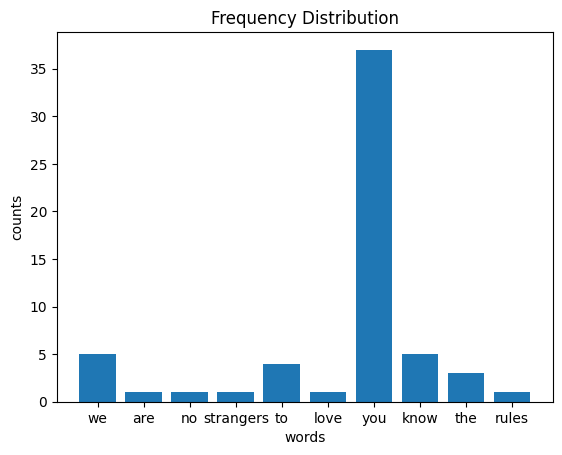

In [16]:
# plot first 10 items of freq distribution
plt.bar(list(freqDist.keys())[0:10], list(freqDist.values())[0:10])
plt.xlabel("words")
plt.ylabel("counts")
plt.title("Frequency Distribution")
plt.show()

### Unigram model

An unigram model is a simple type of language model that considers each word in a sequence independently, without taking into account the previous words. In other words, it models the probability of each word occurring in the text, regardless of what came before it. Unigram models can be seen as a special case of n-gram models, where n is 1.


$ P(\text{"She"}) = \frac{\text{Count}(\text{"She"})}{\text{Total words}}=\frac{2}{8} = 0.250 $

$ P(\text{"enjoys"}) = \frac{\text{Count}(\text{"enjoys"})}{\text{Total words}}=\frac{1}{8} = 0.125 $

$ P(\text{"coffee"}) = \frac{\text{Count}(\text{"coffee"})}{\text{Total words}}=\frac{1}{8} = 0.125 $

$ P(\text{"and"}) = \frac{\text{Count}(\text{"and"})}{\text{Total words}}=\frac{1}{8} = 0.125 $

$ P(\text{"She"}) = \frac{\text{Count}(\text{"She"})}{\text{Total words}}=\frac{2}{8} = 0.250 $

$ P(\text{"likes"}) = \frac{\text{Count}(\text{"likes"})}{\text{Total words}}=\frac{1}{8} = 0.125 $

$ P(\text{"tea"}) = \frac{\text{Count}(\text{"tea"})}{\text{Total words}}=\frac{1}{8} = 0.125 $

$ P(\text{"too"}) = \frac{\text{Count}(\text{"too"})}{\text{Total words}}=\frac{1}{8} = 0.125 $

$P(\text{"She"}, \text{"enjoys"}, \text{"coffee"}, \text{"and"}, \text{"She"}, \text{"likes"}, \text{"tea"}, \text{"too"}) = P(\text{"She"}) \cdot P(\text{"enjoys"}) \cdot P(\text{"coffee"}) \cdot P(\text{"and"}) \cdot P(\text{"She"}) \cdot P(\text{"likes"}) \cdot P(\text{"tea"}) \cdot P(\text{"too"}) = 0.250 \times 0.125 \times 0.125 \times 0.125 \times 0.250 \times 0.125 \times 0.125 \times 0.125$

In general, language models boil down to predicting a sequence of length $t$: $P(W_t, W_{t-1}, ..., W_0)$. In this eight-word sequence, you have:

$P(W_7=\text{"too"}, W_6=\text{"tea"}, W_5=\text{"likes"}, W_4=\text{"She"}, W_3=\text{"and"}, W_2=\text{"coffee"}, W_1=\text{"enjoys"}, W_0=\text{"She"})$

In [18]:
#total count of each word 
count = sum(freqDist.values())
print("Total count of words: ",count)

Total count of words:  385


**The basic idea is iterate through the dictory using vocabulary and get the value (word count) ultimately divide it from the total word count**

In [19]:
vocabulary = set(tokens)
vocabulary

{'a',
 'aching',
 'and',
 'any',
 'are',
 'around',
 'ask',
 'been',
 'blind',
 'both',
 'but',
 'commitments',
 'cry',
 'desert',
 'do',
 'dont',
 'down',
 'each',
 'feeling',
 'for',
 'from',
 'full',
 'game',
 'get',
 'give',
 'going',
 'gon',
 'goodbye',
 'got',
 'guy',
 'hearts',
 'how',
 'hurt',
 'i',
 'if',
 'im',
 'inside',
 'it',
 'just',
 'know',
 'known',
 'let',
 'lie',
 'long',
 'love',
 'make',
 'me',
 'na',
 'never',
 'no',
 'of',
 'on',
 'other',
 'play',
 'rules',
 'run',
 'say',
 'see',
 'shy',
 'so',
 'strangers',
 'ta',
 'tell',
 'the',
 'thinking',
 'this',
 'to',
 'too',
 'understand',
 'up',
 'wan',
 'we',
 'were',
 'weve',
 'what',
 'whats',
 'wouldnt',
 'you',
 'your',
 'youre'}

## Bigram Model

Bigrams represent pairs of consecutive words in the given phrase, i.e., $(w_{t-1},w_t)$. Consider the following words from your example:

Perform the bigram word count for each bigram: $Count(W_{t-1}, W_{t})$

$Count(\text{She, loves}) = 1$

$Count(\text{loves, pizza}) = 1$

$Count(\text{pizza, and}) = 1$

$Count(\text{and, She}) = 1$

$Count(\text{She, enjoys}) = 1$

$Count(\text{enjoys, pasta}) = 1$

$Count(\text{pasta, too}) = 1$

Now, let's calculate the conditional probability for each bigram in the form of $P(w_{t} | w_{t-1})$, where $w_{t-1}$ is the context, and the context size is one.

$P(\text{"loves"} | \text{"She"}) = \frac{\text{Count}(\text{"She, loves"})}{\text{Total count of "She"}} = \frac{1}{2} = 0.5$

$P(\text{"pizza"} | \text{"loves"}) = \frac{\text{Count}(\text{"loves, pizza"})}{\text{Total count of "loves"}} = \frac{1}{1} = 1$

$P(\text{"and"} | \text{"pizza"}) = \frac{\text{Count}(\text{"pizza, and"})}{\text{Total count of "pizza"}} = \frac{1}{1} = 1$

$P(\text{"She"} | \text{"and"}) = \frac{\text{Count}(\text{"and, She"})}{\text{Total count of "and"}} = \frac{1}{1} = 1$

$P(\text{"enjoys"} | \text{"She"}) = \frac{\text{Count}(\text{"She, enjoys"})}{\text{Total count of "She"}} = \frac{1}{2} = 0.5$

$:$

$P(\text{"pasta"} | \text{"enjoys"}) = \frac{\text{Count}(\text{"enjoys, pasta"})}{\text{Total count of "enjoys"}} = \frac{1}{1} = 1$

$P(\text{"too"} | \text{"pasta"}) = \frac{\text{Count}(\text{"pasta, too"})}{\text{Total count of "pasta"}} = \frac{1}{1} = 1$

```bigrams``` is a function provided by the Natural Language Toolkit (NLTK) library in Python. This function takes a sequence of tokens as input and returns an iterator over consecutive pairs of tokens, forming bigrams.


In [20]:
bigrams = nltk.bigrams(tokens)
bigrams

<generator object bigrams at 0x0000016C28FF3060>

In [23]:
my_bigrams = list(nltk.bigrams(tokens))
my_bigrams

[('we', 'are'),
 ('are', 'no'),
 ('no', 'strangers'),
 ('strangers', 'to'),
 ('to', 'love'),
 ('love', 'you'),
 ('you', 'know'),
 ('know', 'the'),
 ('the', 'rules'),
 ('rules', 'and'),
 ('and', 'so'),
 ('so', 'do'),
 ('do', 'i'),
 ('i', 'a'),
 ('a', 'full'),
 ('full', 'commitments'),
 ('commitments', 'what'),
 ('what', 'im'),
 ('im', 'thinking'),
 ('thinking', 'of'),
 ('of', 'you'),
 ('you', 'wouldnt'),
 ('wouldnt', 'get'),
 ('get', 'this'),
 ('this', 'from'),
 ('from', 'any'),
 ('any', 'other'),
 ('other', 'guy'),
 ('guy', 'i'),
 ('i', 'just'),
 ('just', 'wan'),
 ('wan', 'na'),
 ('na', 'tell'),
 ('tell', 'you'),
 ('you', 'how'),
 ('how', 'im'),
 ('im', 'feeling'),
 ('feeling', 'got'),
 ('got', 'ta'),
 ('ta', 'make'),
 ('make', 'you'),
 ('you', 'understand'),
 ('understand', 'never'),
 ('never', 'gon'),
 ('gon', 'na'),
 ('na', 'give'),
 ('give', 'you'),
 ('you', 'up'),
 ('up', 'never'),
 ('never', 'gon'),
 ('gon', 'na'),
 ('na', 'let'),
 ('let', 'you'),
 ('you', 'down'),
 ('down', 'nev

Compute the frequency distribution of the bigram $C(w_{t},w_{t-1})$ using the NLTK function```bigrams```.


In [24]:
freq_dist_bigram = nltk.FreqDist(nltk.bigrams(tokens))
freq_dist_bigram

FreqDist({('gon', 'na'): 38, ('never', 'gon'): 36, ('you', 'never'): 9, ('na', 'tell'): 8, ('make', 'you'): 8, ('na', 'give'): 6, ('give', 'you'): 6, ('you', 'up'): 6, ('up', 'never'): 6, ('na', 'let'): 6, ...})

In [25]:
freq_dist_bigram[('we','are')]

1

In [36]:
word = "strangers"
vocab_prob = {}

for next_word in vocabulary:
    vocab_prob[next_word] = freq_dist_bigram[(word, next_word)]/freqDist[word]
    
vocab_prob = sorted(vocab_prob.items(), reverse=True, key= lambda x: x[1])

In [37]:
vocab_prob[0:4]

[('to', 1.0), ('run', 0.0), ('ta', 0.0), ('both', 0.0)]

Create a function to calculate the conditional probability of $W_t$ given $W_{t-1}$, sort the results, and output them as a list.
